In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_models.caravanify import Caravanify, CaravanifyConfig


---

In [3]:
CA_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

CH_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CH",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

CL_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CL/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CL",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

USA_config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/USA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="USA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

In [4]:
CA_caravan = Caravanify(CA_config)
CH_caravan = Caravanify(CH_config)
CL_caravan = Caravanify(CL_config)
USA_caravan = Caravanify(USA_config)

CA_basins = CA_caravan.get_all_gauge_ids()
CH_basins = CH_caravan.get_all_gauge_ids()
CL_basins = CL_caravan.get_all_gauge_ids()
USA_basins = USA_caravan.get_all_gauge_ids()

# Load all stations
CA_caravan.load_stations(CA_basins)
CH_caravan.load_stations(CH_basins)
CL_caravan.load_stations(CL_basins)
USA_caravan.load_stations(USA_basins)

import gc


def get_daily_counts(caravan_instance):
    # Extract only necessary columns to minimize memory usage
    ts_df = caravan_instance.get_time_series()[["gauge_id", "date", "streamflow"]]

    # Process in place to avoid extra copy
    ts_df = ts_df.dropna(subset=["streamflow"])

    # Count the number of unique gauge_ids for each date
    daily_counts = ts_df.groupby("date")["gauge_id"].nunique().reset_index()
    daily_counts.columns = ["date", "basin_count"]

    # Clean up memory
    del ts_df
    gc.collect()  # Explicitly trigger garbage collection

    return daily_counts


CA_daily_counts = get_daily_counts(CA_caravan)
CH_daily_counts = get_daily_counts(CH_caravan)
CL_daily_counts = get_daily_counts(CL_caravan)
USA_daily_counts = get_daily_counts(USA_caravan)


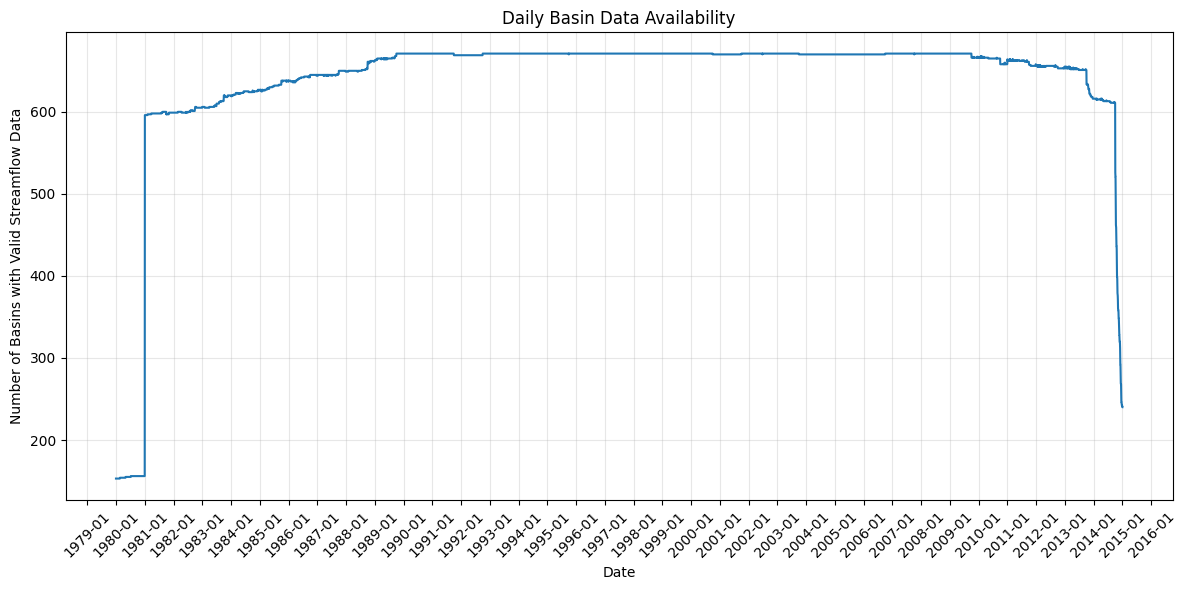

In [6]:
import matplotlib.dates as mdates

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(USA_daily_counts['date'], USA_daily_counts['basin_count'])

# Format the x-axis to show dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Number of Basins with Valid Streamflow Data')
plt.title('Daily Basin Data Availability')
plt.grid(True, alpha=0.3)

# Add some padding to make the plot look better
plt.tight_layout()

plt.show()

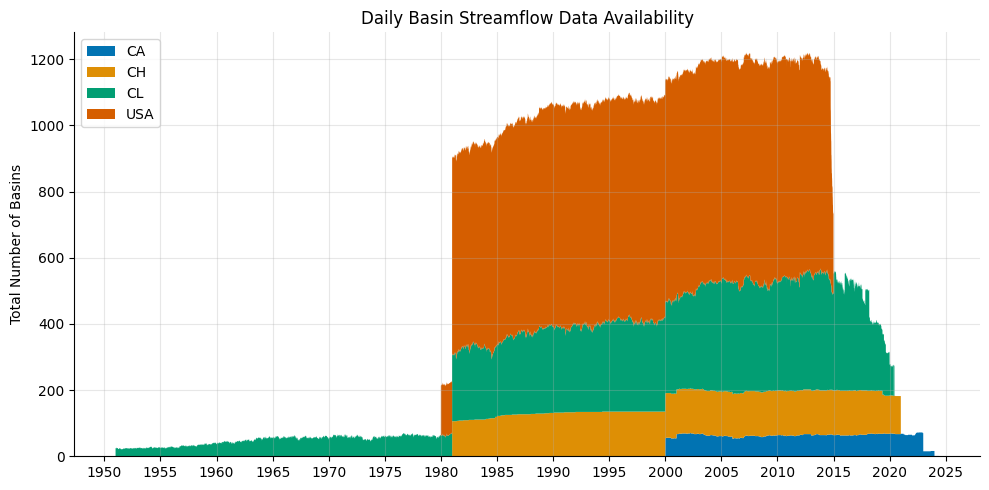

In [ ]:
import seaborn as sns

# Merge the daily counts from the different regions on 'date'
all_dates = pd.DataFrame(
    {
        "date": pd.to_datetime(
            sorted(
                set(CA_daily_counts["date"])
                | set(CH_daily_counts["date"])
                | set(CL_daily_counts["date"])
                | set(USA_daily_counts["date"])
            )
        )
    }
)

all_counts = (
    all_dates.merge(
        CA_daily_counts.rename(columns={"basin_count": "CA"}), on="date", how="left"
    )
    .merge(CH_daily_counts.rename(columns={"basin_count": "CH"}), on="date", how="left")
    .merge(CL_daily_counts.rename(columns={"basin_count": "CL"}), on="date", how="left")
    .merge(
        USA_daily_counts.rename(columns={"basin_count": "USA"}), on="date", how="left"
    )
)

all_counts.fillna(0, inplace=True)
all_counts.sort_values("date", inplace=True)

# Filter for dates from 1980 onwards
# all_counts = all_counts[all_counts['date'] >= '1980-01-01']

plt.figure(figsize=(10, 5))
colors = sns.color_palette("colorblind", 4)
plt.stackplot(
    all_counts['date'],
    all_counts['CA'],
    all_counts['CH'],
    all_counts['CL'],
    all_counts['USA'],
    labels=['CA', 'CH', 'CL', 'USA'],
    colors=colors
)

# Format the x-axis to show dates every 5 years
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

plt.ylabel('Total Number of Basins with Streamflow Data')
plt.title('Daily Basin Streamflow Data Availability')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()

plt.show()
